## Section 0 - Environmental Setup & Log Schema

In [1]:
import vertical_clustering as vc

import os # Used to create a structured output directory per abstraction level "k"
from dataclasses import dataclass   # Defines confirguration objects
from typing import Dict, List, Tuple # Helps in distinguising between event classes, macro activites, and abstraction levels(k)

import numpy as np # Supports efficient matrix operation for event-class corellation matrix
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram # Used to visualize event-class ehirarchy(dendogram)


# ========= pm4py Imports ==========
from pm4py.objects.log.obj import EventLog, Trace, Event
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.conversion.process_tree import converter as process_tree_converter
from pm4py.visualization.bpmn import visualizer as bpmn_visualizer

# ========= Clustering ==========
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.preprocessing import MinMaxScaler

# ========= Semantic Naming (optional) ==========
from sklearn.feature_extraction.text import TfidfVectorizer

# ========= Constants ==========
CASE_COL = "case:concept:name"
TS_COL = "time:timestamp"
ACTIVITY_COL = "activity"
CONCEPT_COL = "concept:name"
OUTPUT_DIR = "ircc_vertical_conformance_samp300v3"


## Section 1 - Data Loading and Configuration

In [2]:
csv_path = "df_sampled_300_cases.csv"

print(f"[INFO] Loading CSV: {csv_path}")
df = vc.load_ircc_csv(csv_path)
display(df.head(10))


[INFO] Loading CSV: df_sampled_300_cases.csv


,case:concept:name,time:timestamp,act_upd_by,activity_id,group,activity,activity_status,cor,citz,concept:name
0,23,2024-06-03 11:19:14.347,0,1-SQ3DESX,1-SQ3ADPW,Application Status,Prospective,Bhutan,Bhutan,Application_Status_-_Prospective
1,23,2024-06-03 11:19:14.347,1,0,1-SQ3ADPW,Misrepresentation,NIL,Bhutan,Bhutan,Misrepresentation_-_NIL
2,23,2024-06-03 11:19:14.347,1,0,1-SQ3ADPW,Eligibility Assessment,NIL,Bhutan,Bhutan,Eligibility_Assessment_-_NIL
3,23,2024-06-03 11:19:14.347,1,0,1-SQ3ADPW,Final Assessment,NIL,Bhutan,Bhutan,Final_Assessment_-_NIL
4,23,2024-06-03 11:19:14.347,1,0,1-SQ3ADPW,Received,Date,Bhutan,Bhutan,Received_-_Date
5,23,2024-06-03 11:19:16.517,55,1-SQ3DESX,1-SQ3ADPW,Biometric Assessment,Required,Bhutan,Bhutan,Biometric_Assessment_-_Required
6,23,2024-06-03 11:19:16.650,3,1-SQ3DEV9,1-SQ3ADPW,Criminality,Not Started,Bhutan,Bhutan,Criminality_-_Not_Started
7,23,2024-06-03 11:19:16.780,55,1-SQ3DESX,1-SQ3ADPW,Criminality Assessment,Not Started,Bhutan,Bhutan,Criminality_Assessment_-_Not_Started
8,23,2024-06-03 11:19:17.053,3,1-SQ3DEV9,1-SQ3ADPW,Criminality,In Progress,Bhutan,Bhutan,Criminality_-_In_Progress
9,23,2024-06-03 11:19:17.177,55,1-SQ3DESX,1-SQ3ADPW,Criminality Assessment,In Progress,Bhutan,Bhutan,Criminality_Assessment_-_In_Progress


In [3]:
# Window/attenuation still matter: they change correlations and thus the hierarchy.
cfg = vc.SegmentationConfig(window_size=12, attenuation=0.5, linkage_method="complete")


## Section 2 - Event Class Correlation (Global Scan)


In [4]:
'''
This is the first substantive methodological step.

Everything that follows, like hierarchy, abstraction levels, segmentation, models all depends entirely on this output.
'''

print("[INFO] Computing event-class correlation (global scan)...")
corr, classes = vc.compute_event_class_correlation(df, ACTIVITY_COL, cfg)


[INFO] Computing event-class correlation (global scan)...


Correlation matrix shape: (33, 33)

Sample view (first 12 rows/columns):


,Application Status,Application Transfer,Associate Medicals,Auto Promote,Auto Promote Decision,Biographic,Biometric - FCC - NZ,Biometric - FCC - USA,Biometric - FCC Detail - USA,Biometric Assessment,Biometrics - RCMP,Biometrics Family Rate Fee
Application Status,0.001047,0.005629,0.000238,0.172236,0.060954,0.142423,0.003293,0.083010,0.006713,0.010757,0.008585,0.000032
Application Transfer,0.005629,0.025588,0.000172,0.002189,0.004310,0.067521,0.002493,0.035260,0.003705,0.009911,0.068648,0.000000
Associate Medicals,0.000238,0.000172,0.018218,0.004816,0.004170,0.004168,0.000000,0.000965,0.000000,0.000821,0.003140,0.000000
Auto Promote,0.172236,0.002189,0.004816,0.483989,0.507492,0.165844,0.010969,0.086952,0.001213,0.000835,0.074885,0.000000
Auto Promote Decision,0.060954,0.004310,0.004170,0.507492,0.175042,0.166391,0.007358,0.053232,0.002274,0.000800,0.050116,0.000000
Biographic,0.142423,0.067521,0.004168,0.165844,0.166391,0.672342,0.019838,0.222883,0.012773,0.016693,0.205332,0.000000
Biometric - FCC - NZ,0.003293,0.002493,0.000000,0.010969,0.007358,0.019838,0.009714,0.052966,0.006848,0.001638,0.002514,0.000000
Biometric - FCC - USA,0.083010,0.035260,0.000965,0.086952,0.053232,0.222883,0.052966,0.492969,0.087439,0.054661,0.070640,0.000000
Biometric - FCC Detail - USA,0.006713,0.003705,0.000000,0.001213,0.002274,0.012773,0.006848,0.087439,0.102432,0.002442,0.001110,0.000000
Biometric Assessment,0.010757,0.009911,0.000821,0.000835,0.000800,0.016693,0.001638,0.054661,0.002442,0.000000,0.139728,0.000247


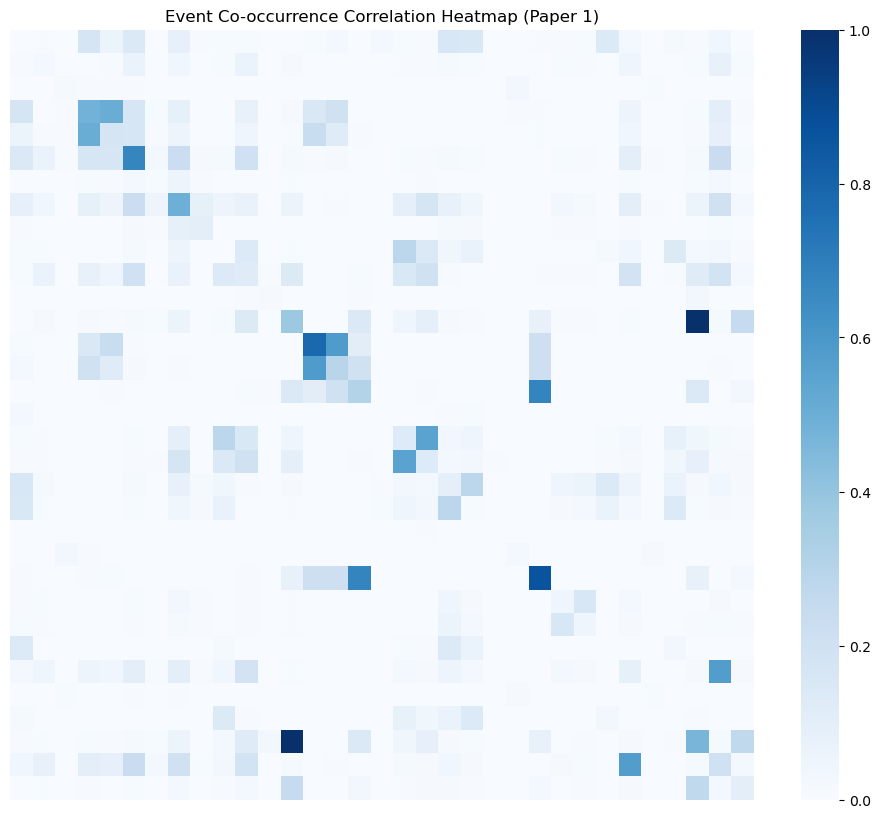

In [5]:
# ====== VISUALIZATION BLOCK ======
corr_df = pd.DataFrame(corr, index=classes, columns=classes) # Convert the correlation matrix into a labeled table where
                                                              # 1. rows and columns = event classes
                                                              # 2. values = behavioral proximity (i.e. correlation)
'''
This block just visualizes the global event-class correlation matrix computed in the previous step. High values indicate 
activities that tend to occur close together in traces, which often correspond to the same subprocess domain. 
The visualization is purely diagnostic — it helps understand the structure that the clustering algorithm will summarize, 
but it does not influence abstraction decisions
'''
'''
The matrix visualized here contains correlation values that express behavioral proximity; those correlations are later 
transformed into distances for hierarchical clustering, because clustering operates on dissimilarity rather than similarity.
'''
'''
High correlation -> strong behavioral cohesion
Low correlation -> behavioral independence
Mid-range -> weak or contextual relationship
'''
print("Correlation matrix shape:", corr_df.shape)
print("\nSample view (first 12 rows/columns):")
display(corr_df.iloc[:12, :12])

# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Event Co-occurrence Correlation Heatmap (Paper 1)")
plt.show()

## Section 3 - Event Class Heirarchy Construction

In [6]:
'''
This is the transition point from behavioral evidence (correlation) -> abstraction structure (hierarchy)

Everything after this is projection, not clustering.
'''
print("[INFO] Building event-class hierarchy (linkage matrix)...")
Z = vc.build_event_class_hierarchy(corr, cfg)


[INFO] Building event-class hierarchy (linkage matrix)...


[INFO] Visualizing dendrogram and abstraction levels...


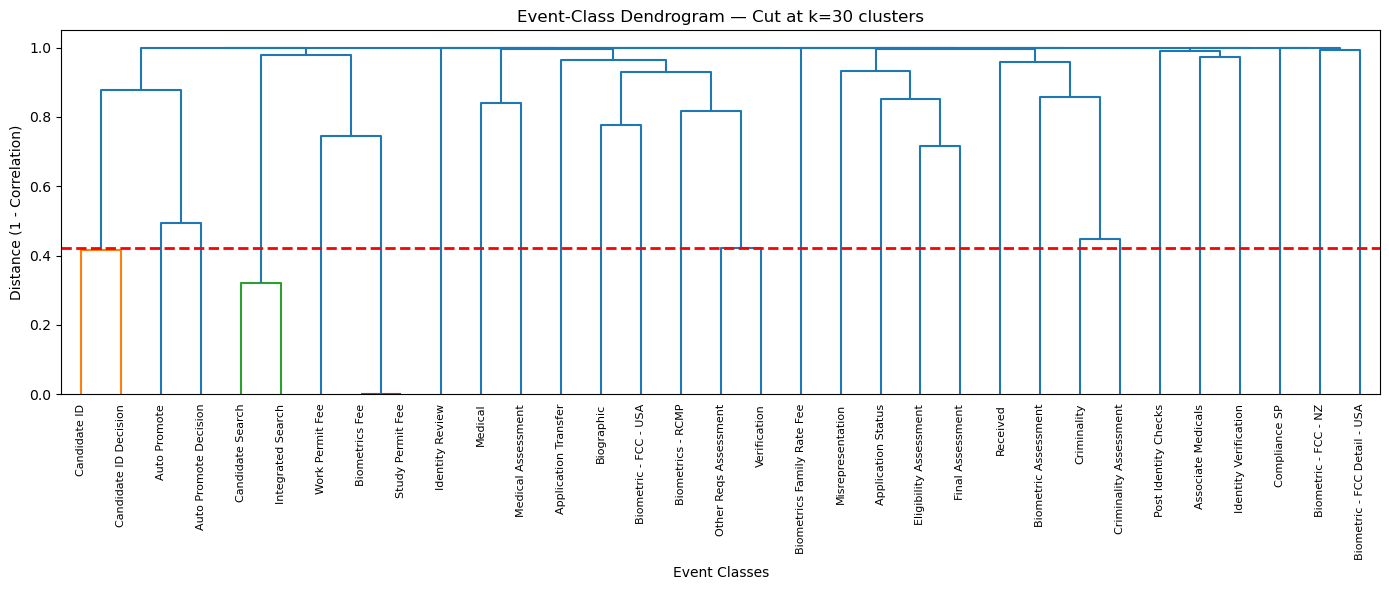

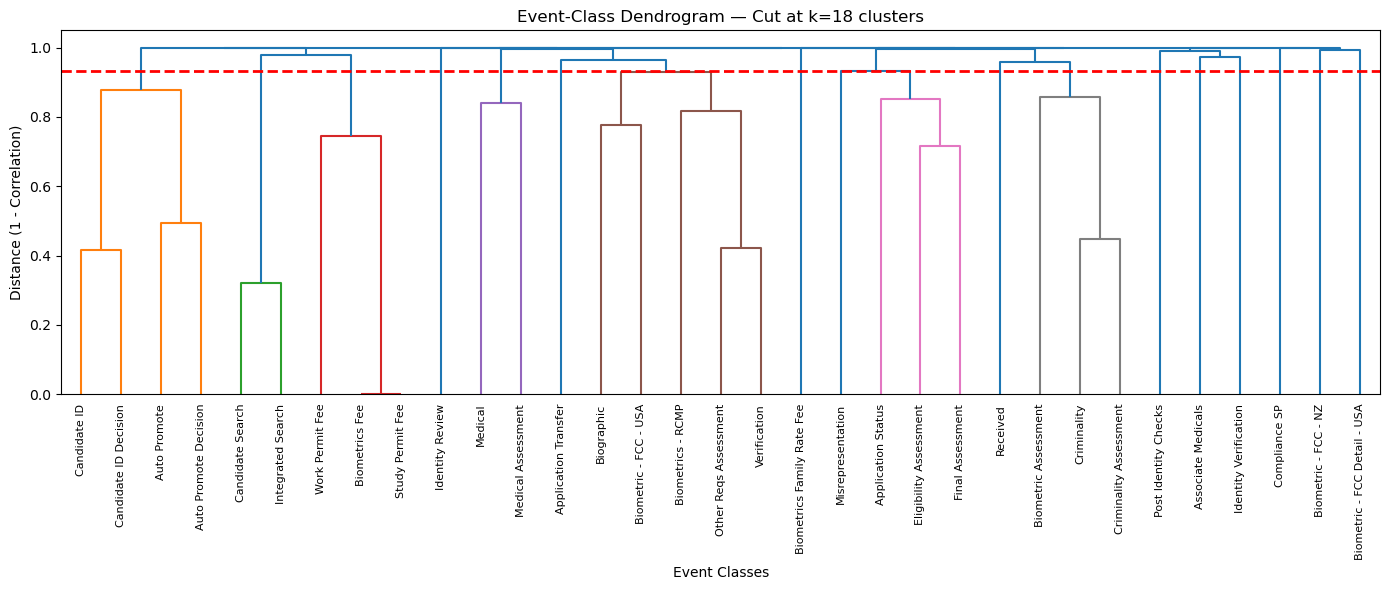

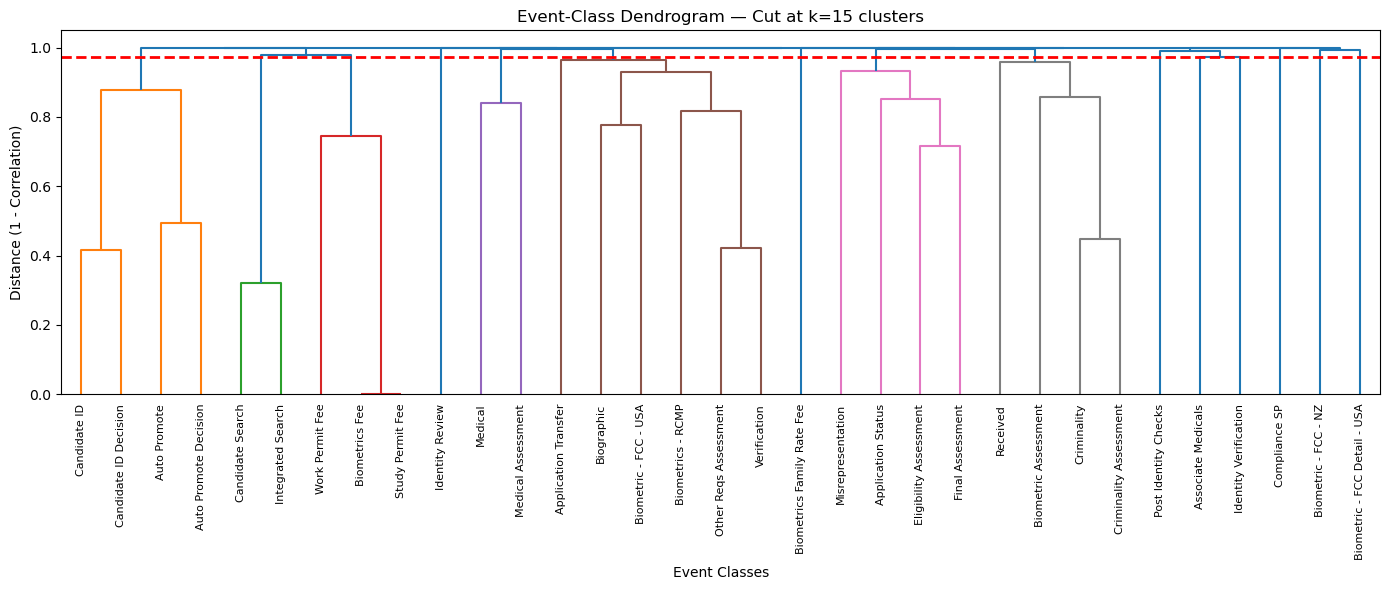

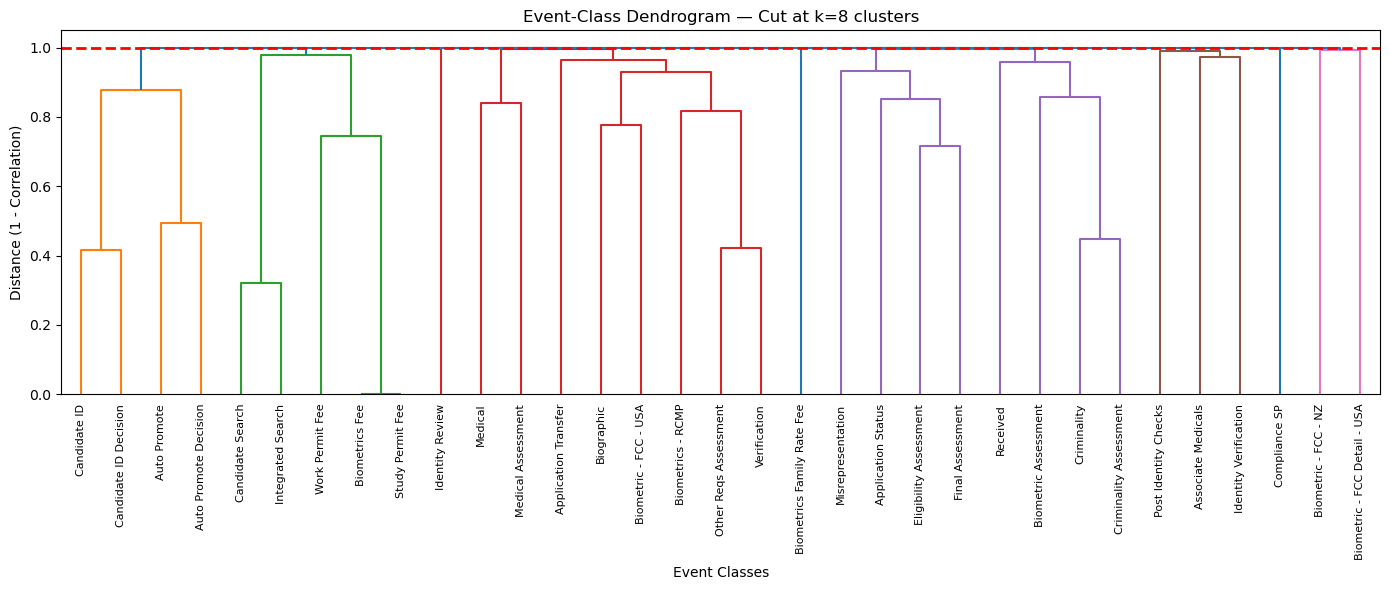

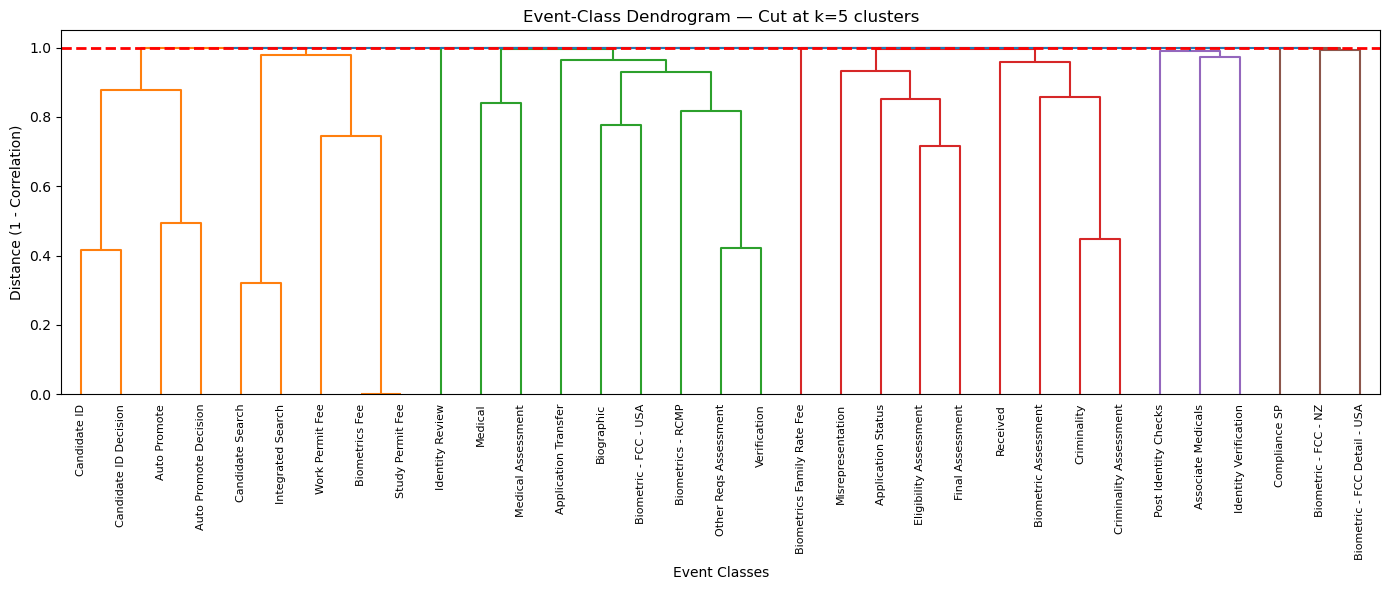

In [7]:
# ============================================================
# VISUALIZE EVENT-CLASS DENDROGRAM + ABSTRACTION LEVEL CUTS
# ============================================================
'''
Choose multiple abstraction levels like Fig. 3 (fine -> coarse).
               Larger k = more clusters = closer to raw detail. 
               Smaller k = more abstract.
'''
'''
Paper alignment:
This directly mirrors the idea in Günther’s Figure 3:
- explore multiple abstraction levels
- from fine-grained to coarse-grained

Key ownership sentence:
There is no single correct abstraction level; usefulness depends on analysis goals.
'''    
k_levels = [30, 18, 15, 8, 5]

print("[INFO] Visualizing dendrogram and abstraction levels...")
for k in k_levels: # for each abstraction level value in k_levels plot their respective dendogram
    h = vc.get_cut_height_for_k(Z, k)  # get cut height for the single matrix at each abstraction level
    vc.plot_event_class_dendrogram(
        Z,
        labels=classes,
        max_d=h,
        title=f"Event-Class Dendrogram — Cut at k={k} clusters"
    )



## Section 4 - Adaptive Global Trace Segmentation

In [8]:
# ------------------------------------------------------------
# ADAPTIVE GLOBAL TRACE SEGMENTATION (Figure 3 in Günther et al.)
#
# Applies a globally-defined abstraction mapping to all traces.
#
# Steps:
# 1. Replace each activity with its macro activity.
# 2. Collapse consecutive repetitions of the same macro activity.
#
# Segmentation in this context means deterministic trace rewriting
# induced by a global abstraction level, not local boundary detection.
# ------------------------------------------------------------


'''
“Once the hierarchy cut gives a fixed mapping from activities to macro activities, apply that mapping to every event in 
every trace. That’s the rewrite step. Then apply the Figure 3 collapse step: consecutive repetitions of the same 
macro activity are merged. This creates macro-level segments without any local boundary detection or per-trace
optimization it’s deterministic rewriting driven by the chosen abstraction level.
'''

'\n“Once the hierarchy cut gives a fixed mapping from activities to macro activities, apply that mapping to every event in \nevery trace. That’s the rewrite step. Then apply the Figure 3 collapse step: consecutive repetitions of the same \nmacro activity are merged. This creates macro-level segments without any local boundary detection or per-trace\noptimization it’s deterministic rewriting driven by the chosen abstraction level.\n'

## Section 4.1 - Abstraction and Projection of Mapping

In [9]:
# ============================================================
# PHASE A — ABSTRACTION & PROJECTION (Günther et al.)
# ============================================================
'''
Phase A selects abstraction levels by cutting the global event-class hierarchy and then projects those abstractions onto 
the log using deterministic trace rewriting and collapse, exactly as shown in Günther’s Figure 3.

Key takeaways (simple and defensible)
- Hierarchy built once
- Abstraction levels selected by cuts
- Projection and global
- Segmentation is deterministic
- No trace-level optimization
'''

# --- Phase A: abstraction + projection ---
abstracted_logs, mappings = vc.build_abstracted_logs(
    df=df,
    Z=Z,
    classes=classes,
    k_levels=k_levels,
    do_collapse=True
)



In [10]:
k = 15
df_macro_ids = abstracted_logs[k]


print("=== After macro cluster ID assignment ===")
display(
    df_macro_ids[
        [CASE_COL, TS_COL, ACTIVITY_COL, "macro_activity_id"]
    ].head(20)
)


=== After macro cluster ID assignment ===


,case:concept:name,time:timestamp,activity,macro_activity_id
0,23,2024-06-03 11:19:14.347,Application Status,6
1,23,2024-06-03 11:19:14.347,Received,7
2,23,2024-06-03 11:19:17.340,Biometrics - RCMP,4
3,23,2024-06-03 11:19:32.000,Biometrics Family Rate Fee,8
4,23,2024-06-03 11:19:32.000,Study Permit Fee,2
5,23,2024-06-03 11:19:32.000,Biometrics Family Rate Fee,8
6,23,2024-06-03 11:19:32.000,Study Permit Fee,2
7,23,2024-06-03 11:19:34.000,Biometrics Family Rate Fee,8
8,23,2024-06-03 11:19:34.000,Study Permit Fee,2
9,23,2024-06-03 11:19:34.000,Biometrics Family Rate Fee,8


## Section 5 - TF-IDF Semantic Naming for Interpretable Macro Labels

In [11]:
# ============================================================
# PHASE B — SEMANTIC NAMING 
# Everything up to Phase A defines abstraction behavior; Phase B only improves readability
# ============================================================

# --- Phase B: semantic naming ---
clustered_logs, semantic_labels = vc.apply_semantic_naming_to_logs(
    abstracted_logs,
    mappings,
    top_k_terms=2
)


In [12]:
k = 15
df_named = clustered_logs[k]

display(
    df_named[
        [CASE_COL, TS_COL, ACTIVITY_COL, "macro_activity_id", "macro_activity"]
    ].head(30)
)


,case:concept:name,time:timestamp,activity,macro_activity_id,macro_activity
0,23,2024-06-03 11:19:14.347,Application Status,6,Assessment Misrepresentation
1,23,2024-06-03 11:19:14.347,Received,7,Criminality Assessment
2,23,2024-06-03 11:19:17.340,Biometrics - RCMP,4,Verification Biographic
3,23,2024-06-03 11:19:32.000,Biometrics Family Rate Fee,8,Rate Fee
4,23,2024-06-03 11:19:32.000,Study Permit Fee,2,Fee Permit
5,23,2024-06-03 11:19:32.000,Biometrics Family Rate Fee,8,Rate Fee
6,23,2024-06-03 11:19:32.000,Study Permit Fee,2,Fee Permit
7,23,2024-06-03 11:19:34.000,Biometrics Family Rate Fee,8,Rate Fee
8,23,2024-06-03 11:19:34.000,Study Permit Fee,2,Fee Permit
9,23,2024-06-03 11:19:34.000,Biometrics Family Rate Fee,8,Rate Fee


## Section 6 - BPMN Discovery & Multi-Level Visualization

In [13]:
# ============================================================
# PHASE C — BPMN DISCOVERY & VISUALIZATION
# "Alphabet" = vocabulary of event labels
# ============================================================

# --- Phase C: BPMN discovery & export ---
for k in k_levels:  # for each abstraction level, process independently
    level_dir = os.path.join(OUTPUT_DIR, f"level_k_{k}")
    vc.ensure_output_dirs(level_dir)

    print("\n===============================")
    print(f"[INFO] Abstraction level: k = {k}")
    print(f"[INFO] Output dir: {level_dir}")
    print("===============================")

    vc.generate_all_bpmns_for_level(
        df_raw=df,
        df_macro=clustered_logs[k],
        mapping=mappings[k],
        sem_labels=semantic_labels[k],
        base_dir=level_dir
    )

    print(f"[DONE] Level k={k} complete -> {level_dir}")


[INFO] Abstraction level: k = 30
[INFO] Output dir: ircc_vertical_conformance_samp300v3\level_k_30
[INFO] Discovering Global BPMN...
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_30\bpmn_global\global_macro_bpmn.png
[INFO] Discovering Macro Subprocess BPMNs...
[INFO] Macro subprocess BPMN -> Biographic
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_30\bpmn_macro\macro_Biographic.png
[INFO] Macro subprocess BPMN -> Biometric Assessment
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_30\bpmn_macro\macro_Biometric_Assessment.png
[INFO] Macro subprocess BPMN -> Criminality
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_30\bpmn_macro\macro_Criminality.png
[INFO] Macro subprocess BPMN -> Criminality Assessment
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_30\bpmn_macro\macro_Criminality_Assessment.png
[INFO] Macro subprocess BPMN -> Eligibility Assessment
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_30\bp

[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_30\bpmn_activity_lifecycle\Criminality\activity_lifecycle_Criminality.png
[INFO] Lifecycle BPMN -> Criminality Assessment (Cluster 'Criminality Assessment')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_30\bpmn_activity_lifecycle\Criminality_Assessment\activity_lifecycle_Criminality_Assessment.png
[INFO] Lifecycle BPMN -> Eligibility Assessment (Cluster 'Eligibility Assessment')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_30\bpmn_activity_lifecycle\Eligibility_Assessment\activity_lifecycle_Eligibility_Assessment.png
[INFO] Lifecycle BPMN -> Final Assessment (Cluster 'Final Assessment')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_30\bpmn_activity_lifecycle\Final_Assessment\activity_lifecycle_Final_Assessment.png
[INFO] Lifecycle BPMN -> Identity Review (Cluster 'Review Identity')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_30\bpmn_activity_lifecycle\Review_Ident

[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_18\bpmn_activity_lifecycle\Criminality_Assessment\activity_lifecycle_Biometric_Assessment.png
[INFO] Lifecycle BPMN -> Biometrics - RCMP (Cluster 'Verification Biographic')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_18\bpmn_activity_lifecycle\Verification_Biographic\activity_lifecycle_Biometrics_-_RCMP.png
[INFO] Lifecycle BPMN -> Biometrics Family Rate Fee (Cluster 'Rate Fee')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_18\bpmn_activity_lifecycle\Rate_Fee\activity_lifecycle_Biometrics_Family_Rate_Fee.png
[INFO] Lifecycle BPMN -> Biometrics Fee (Cluster 'Fee Permit')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_18\bpmn_activity_lifecycle\Fee_Permit\activity_lifecycle_Biometrics_Fee.png
[INFO] Lifecycle BPMN -> Candidate ID (Cluster 'Promote Id')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_18\bpmn_activity_lifecycle\Promote_Id\activity_lifecycle_Candidate_ID.p

[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_15\bpmn_activity_lifecycle\Promote_Id\activity_lifecycle_Auto_Promote.png
[INFO] Lifecycle BPMN -> Auto Promote Decision (Cluster 'Promote Id')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_15\bpmn_activity_lifecycle\Promote_Id\activity_lifecycle_Auto_Promote_Decision.png
[INFO] Lifecycle BPMN -> Biographic (Cluster 'Verification Biographic')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_15\bpmn_activity_lifecycle\Verification_Biographic\activity_lifecycle_Biographic.png
[INFO] Lifecycle BPMN -> Biometric - FCC - NZ (Cluster 'Nz Fcc')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_15\bpmn_activity_lifecycle\Nz_Fcc\activity_lifecycle_Biometric_-_FCC_-_NZ.png
[INFO] Lifecycle BPMN -> Biometric - FCC - USA (Cluster 'Verification Biographic')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_15\bpmn_activity_lifecycle\Verification_Biographic\activity_lifecycle_Biometric_-_FCC

[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_8\bpmn_activity_lifecycle\Assessment_Criminality\activity_lifecycle_Application_Status.png
[INFO] Lifecycle BPMN -> Application Transfer (Cluster 'Medical Assessment')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_8\bpmn_activity_lifecycle\Medical_Assessment\activity_lifecycle_Application_Transfer.png
[INFO] Lifecycle BPMN -> Associate Medicals (Cluster 'Identity Verification')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_8\bpmn_activity_lifecycle\Identity_Verification\activity_lifecycle_Associate_Medicals.png
[INFO] Lifecycle BPMN -> Auto Promote (Cluster 'Promote Id')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_8\bpmn_activity_lifecycle\Promote_Id\activity_lifecycle_Auto_Promote.png
[INFO] Lifecycle BPMN -> Auto Promote Decision (Cluster 'Promote Id')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_8\bpmn_activity_lifecycle\Promote_Id\activity_lifecycle_Auto_Promo

[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_5\bpmn_activity_lifecycle\Assessment_Criminality\activity_lifecycle_Application_Status.png
[INFO] Lifecycle BPMN -> Application Transfer (Cluster 'Medical Assessment')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_5\bpmn_activity_lifecycle\Medical_Assessment\activity_lifecycle_Application_Transfer.png
[INFO] Lifecycle BPMN -> Associate Medicals (Cluster 'Identity Verification')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_5\bpmn_activity_lifecycle\Identity_Verification\activity_lifecycle_Associate_Medicals.png
[INFO] Lifecycle BPMN -> Auto Promote (Cluster 'Candidate Fee')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_5\bpmn_activity_lifecycle\Candidate_Fee\activity_lifecycle_Auto_Promote.png
[INFO] Lifecycle BPMN -> Auto Promote Decision (Cluster 'Candidate Fee')
[OK] BPMN PNG -> ircc_vertical_conformance_samp300v3\level_k_5\bpmn_activity_lifecycle\Candidate_Fee\activity_lifecycl

## Section 7 - Evaluation and Comparison


[INFO] Computing evaluation metrics (paper-faithful)...


replaying log with TBR, completed traces ::   0%|          | 0/300 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/12397 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/299 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/8830 [00:00<?, ?it/s]

...

replaying log with TBR, completed traces ::   0%|          | 0/284 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/1922 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/257 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/1119 [00:00<?, ?it/s]


=== Log Complexity Metrics ===
  Abstraction  # Event Classes  # Traces  Avg Trace Length  # Trace Variants  \
0     Raw log               33       300             69.09               300   
1      k = 30               29       300             46.23               298   
2      k = 18               18       300             21.42               239   
3      k = 15               15       300             17.29               199   
4       k = 8                8       300             14.75               167   
5       k = 5                5       300             12.55               123   

   Variability Ratio  # DFG Edges  
0              1.000          802  
1              0.993          845  
2              0.797          648  
3              0.663          622  
4              0.557          539  
5              0.410          473  

=== BPMN Complexity Metrics ===
  Abstraction  # BPMN Nodes  # BPMN Flows  # BPMN Tasks
0     Raw log           435           618           137
1      k =

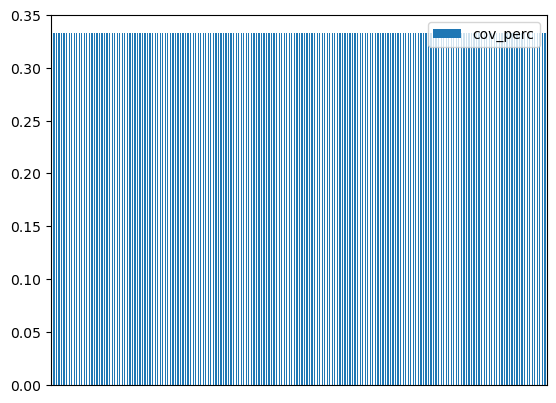

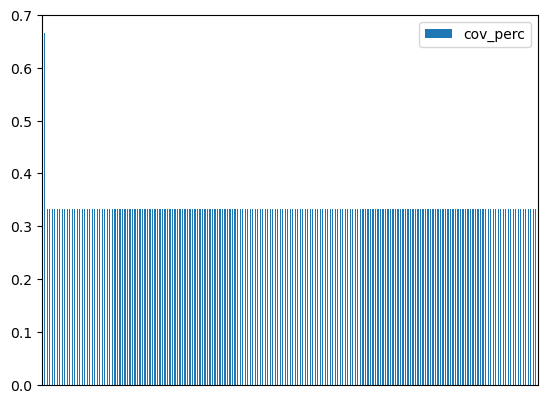

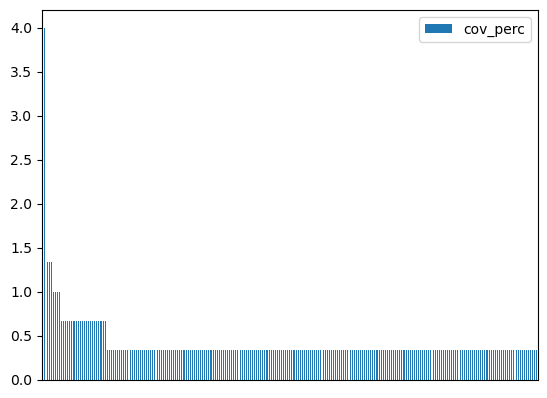

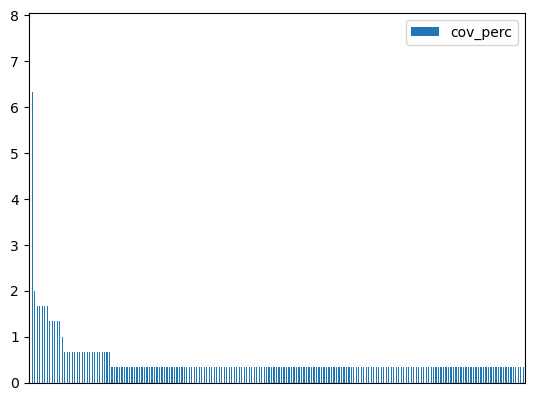

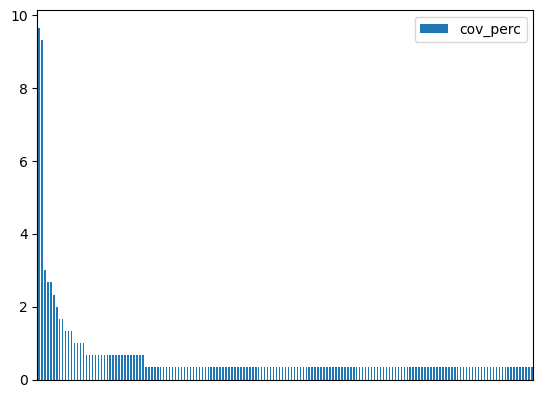

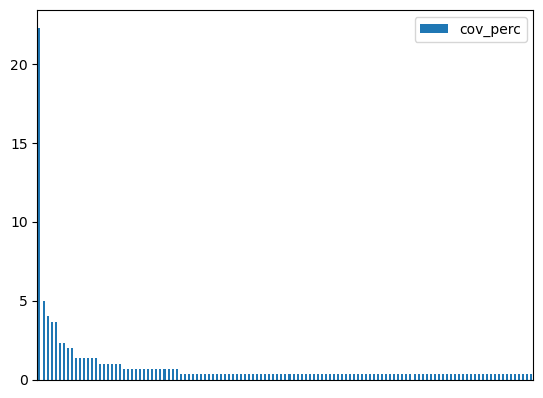

In [14]:
# ============================================================
# STEP 6 — EVALUATION METRICS (Paper-faithful comparison)
# Does global trace segmentation produce a log that leads to simpler, more understandable 
#  process models?
# ============================================================

# ============================================================
# STEP 6 — PAPER-FAITHFUL EVALUATION 
# ============================================================
print("\n[INFO] Computing evaluation metrics (paper-faithful)...")

log_complexity_table = vc.build_log_complexity_table(
    raw_df=df,
    clustered_dfs=clustered_logs,
    label_col_raw=ACTIVITY_COL,
    label_col_macro="macro_activity"
)

bpmn_complexity_table = vc.build_bpmn_complexity_table(
    raw_df=df,
    clustered_dfs=clustered_logs,
    label_col_raw=ACTIVITY_COL,
    label_col_macro="macro_activity"
)
    
conformance_table = vc.build_conformance_table(
    raw_df=df,
    clustered_dfs=clustered_logs,
    label_col_raw=ACTIVITY_COL,
    label_col_macro="macro_activity"
)

print("\n=== Log Complexity Metrics ===")
print(log_complexity_table)

print("\n=== BPMN Complexity Metrics ===")
print(bpmn_complexity_table)
    
print("\n=== Conformance Metrics ===")
print(conformance_table)

log_complexity_table.to_csv(
    os.path.join(OUTPUT_DIR, "log_complexity_metrics.csv"),
    index=False
)
bpmn_complexity_table.to_csv(
    os.path.join(OUTPUT_DIR, "bpmn_complexity_metrics.csv"),
    index=False
)
    
conformance_table.to_csv(
    os.path.join(OUTPUT_DIR, "conformance_metrics.csv"),
    index=False
)

print("\n🎉 ALL DONE — outputs saved under:", OUTPUT_DIR)